# 003 — Isolation Forest on normal transactions

Step 1.3: fit the forest on **normal training rows only**, then score the untouched test set. Full evaluation (PR-AUC, thresholds) is Step 1.5; here we check the model trains, scores, and points in the right direction.

## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import time
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import settings
from src.ml.preprocess import load_splits
from src.ml.isolation_forest import fit_on_normal, normal_only

pd.set_option("display.float_format", "{:.4f}".format)

## 2. Load the saved splits

In [2]:
X_train, X_test, y_train, y_test = load_splits()
X_normal = normal_only(X_train, y_train)

print(f"train: {len(X_train):,} rows ({y_train.sum()} fraud)")
print(f"forest trains on: {len(X_normal):,} normal rows (holds out {len(X_train) - len(X_normal)} fraud)")
print(f"test:  {len(X_test):,} rows ({y_test.sum()} fraud), untouched until scoring")

train: 226,980 rows (378 fraud)
forest trains on: 226,602 normal rows (holds out 378 fraud)
test:  56,746 rows (95 fraud), untouched until scoring


## 3. Fit

In [3]:
start = time.perf_counter()
model = fit_on_normal(X_train, y_train)
print(f"fit in {time.perf_counter() - start:.1f}s")

forest = model.named_steps["model"]
print(f"trees: {len(forest.estimators_)} | rows sampled per tree: {forest.max_samples_} | features: {forest.n_features_in_}")
model

fit in 3.3s
trees: 200 | rows sampled per tree: 256 | features: 31


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('amount', ...), ('time', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


## 4. Why it trains so fast: small, shallow trees

In [4]:
depth_limit = int(np.ceil(np.log2(forest.max_samples_)))
depths = [tree.get_depth() for tree in forest.estimators_]
print(f"depth limit: {depth_limit}  (= ceil(log2({forest.max_samples_})))")
print(f"actual tree depths: min {min(depths)}, max {max(depths)}")

depth limit: 8  (= ceil(log2(256)))
actual tree depths: min 8, max 8


## 5. Score the test set

In [5]:
start = time.perf_counter()
test_scores = model.score_samples(X_test)
batch_seconds = time.perf_counter() - start

print(type(test_scores).__name__, test_scores.shape, test_scores.dtype, "| all finite:", np.isfinite(test_scores).all())
print(f"score range: {test_scores.min():.4f} to {test_scores.max():.4f}")
print(f"batch: {len(X_test):,} rows in {batch_seconds:.2f}s = {batch_seconds / len(X_test) * 1e6:.1f} microseconds/row")

one_row = X_test.head(1)
model.score_samples(one_row)  # warm-up
start = time.perf_counter()
for _ in range(50):
    model.score_samples(one_row)
print(f"single row (one API request): {(time.perf_counter() - start) / 50 * 1000:.1f} ms")

ndarray (56746,) float64 | all finite: True
score range: -0.7502 to -0.3569
batch: 56,746 rows in 0.51s = 9.1 microseconds/row


single row (one API request): 9.9 ms


## 6. Scores by class

In [6]:
scores = pd.DataFrame({"score": test_scores, "Class": y_test.to_numpy()})
scores.groupby("Class")["score"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,56651.0000,-0.4139,0.0412,-0.7502,-0.4284,-0.4038,-0.3867,-0.3569
1,95.0000,-0.5716,0.0837,-0.7137,-0.6348,-0.5821,-0.5302,-0.3787


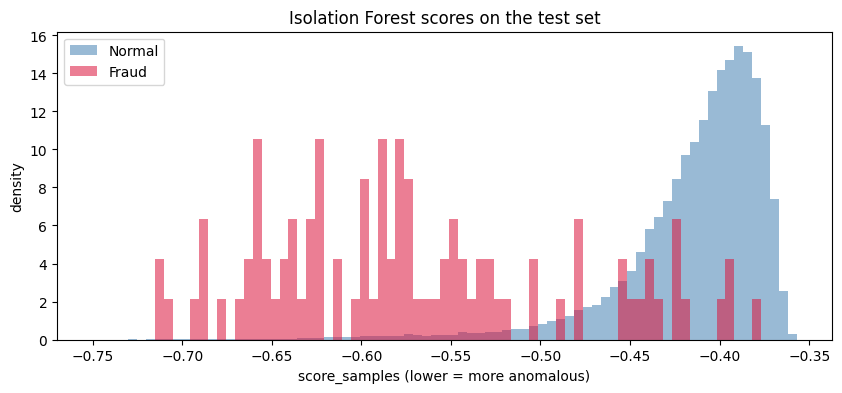

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
bins = np.linspace(test_scores.min(), test_scores.max(), 80)
for label, color, name in [(0, "steelblue", "Normal"), (1, "crimson", "Fraud")]:
    ax.hist(scores.loc[scores["Class"] == label, "score"], bins=bins, density=True,
            alpha=0.55, color=color, label=name)
ax.set_xlabel("score_samples (lower = more anomalous)")
ax.set_ylabel("density")
ax.set_title("Isolation Forest scores on the test set")
ax.legend()
plt.show()

## 7. Does the ranking point the right way?

In [8]:
cutoff = np.quantile(test_scores, 0.01)
lowest = scores[scores["score"] <= cutoff]
expected_by_chance = y_test.mean() * len(lowest)

print(f"lowest-scoring 1% of test rows: {len(lowest)}")
print(f"fraud among them: {lowest['Class'].sum()} of {y_test.sum()}")
print(f"random picking would find about {expected_by_chance:.1f}")
print(f"lift: {lowest['Class'].sum() / expected_by_chance:.0f}x")

lowest-scoring 1% of test rows: 568
fraud among them: 46 of 95
random picking would find about 1.0
lift: 48x


## 8. What `contamination` actually does

In [9]:
print(f"contamination = {forest.contamination}  ->  offset_ = {forest.offset_:.4f}")

flagged = model.predict(X_test) == -1
print(f"predict() flags {flagged.mean():.3%} of test rows")
print(f"fraud caught by predict(): {y_test[flagged].sum()} of {y_test.sum()}")

contamination = 0.0017  ->  offset_ = -0.6452


predict() flags 0.224% of test rows
fraud caught by predict(): 19 of 95


## Step 1.3 findings

**Training**
- Trained on **226,602 normal rows**. All 378 training fraud cases were held out.
- Fit took **3.3 s**. Each of the 200 trees sees only 256 sampled rows and stops at depth 8 = ceil(log2(256)). Training cost barely depends on dataset size.

**Scores** (lower = more anomalous)
- Median score: normal **-0.404**, fraud **-0.582**. The model points the right way.
- The distributions overlap: the least suspicious fraud (-0.379) sits inside the normal range. No threshold will catch everything without false alarms.
- The lowest-scoring **1%** of test rows (568) contains **46 of 95 fraud**, a **48x lift** over random picking (about 48% recall at 8% precision).

**`contamination` is not our decision threshold**
- After training on normal rows only, `contamination=0.0017` only sets `offset_` (-0.645), the 0.17th percentile of *normal* training scores. It doesn't change the trees or how rows are ranked.
- `predict()` using that offset flags 0.224% of test rows and catches only **19 of 95** fraud.
- So we won't use `predict()`. Step 1.4 turns `score_samples` into a 0-1 risk score, and Step 1.6 picks the threshold from the precision/recall curve.

**Latency (matters for Phases 2 and 4)**
- Batch: **9 microseconds per row** (56,746 rows in 0.5 s).
- Single row: **about 10 ms per call**. That is fixed overhead: about 6.5 ms walking 200 trees plus about 2.4 ms of pandas preprocessing. `n_jobs` makes no difference.
- So: 10 ms per API request is acceptable. The **Kafka consumer should score in micro-batches**, not one message at a time.